# CDS Pricer, benchmark and visualisation


In [9]:
import sys
sys.path.insert(0, r'C:\Users\ricar\OneDrive\Documents\Stage Quant Factory\Code\CDS and IndexTranches Pricing\bindings')

import cds_pricer as cds
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import time, statistics

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.3,
})
print('✓ Loaded modules :', cds.__doc__)

✓ Loaded modules : CDS & IndexTranches Pricing — pybind11 bindings


## 1-Market

In [10]:
today = cds.Date(2026, 3, 26)

def build_yield_curve():
    b = cds.YieldCurveBoot(today)
    b.add_deposits([cds.Deposit(1/365,0.039),cds.Deposit(7/365,0.0392),
                    cds.Deposit(1/12,0.0395),cds.Deposit(3/12,0.040)])
    b.add_futures([cds.Future(3/12,6/12,95.90,0.01),cds.Future(6/12,9/12,96.00,0.01),
                   cds.Future(9/12,12/12,96.15,0.01),cds.Future(12/12,15/12,96.30,0.01)])
    b.add_swaps([cds.Swap(2,0.047,0.25,0.25),cds.Swap(3,0.036,0.25,0.25),
                 cds.Swap(5,0.0345,0.25,0.25),cds.Swap(10,0.0338,0.25,0.25)])
    return b

QUOTES = [cds.Point(1,0.005),cds.Point(2,0.008),cds.Point(3,0.010),
          cds.Point(5,0.013),cds.Point(7,0.015),cds.Point(10,0.017)]

def build_credit_curve(yc, rr=0.40):
    md = cds.CDSMarketData()
    md.name=md.name='ACME'; md.effective_date=today; md.valuation_date=today
    md.recovery_rate=rr; md.frequency=cds.Frequency.QUARTERLY; md.quotes=QUOTES
    return cds.CreditBoot(md, yc, today)

def make_cds(mat=5.0, spread=0.013, nominal=10_000_000, rr=0.40):
    i = cds.CDS()
    i.maturity=mat; i.nominal=nominal; i.effective_date=today
    i.valuation_date=today; i.recovery_rate=rr
    i.frequency=cds.Frequency.QUARTERLY; i.contractual_spread=spread
    return i

boot = build_yield_curve()
yc   = boot.curve()
ccb  = build_credit_curve(yc)
cc   = ccb.curve()
print('✓ Yield Curve and Credit Curve are ready')

✓ Yield Curve and Credit Curve are ready


## 2. Benchmark — Execution time per component

In [11]:
N = 1000

def bench(label, fn, n=N):
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        fn()
        times.append((time.perf_counter()-t0)*1e6)  # µs
    med = statistics.median(times)
    p95 = sorted(times)[int(0.95*n)]
    print(f'{label:<40} median={med:7.1f} µs   p95={p95:7.1f} µs')
    return times

instr = make_cds()
pricer = cds.CDSPricer(instr, yc, cc)

print(f'Benchmark on {N} itérations\n{"="*65}')
t_boot_yc  = bench('YieldCurve bootstrap',   lambda: build_yield_curve())
t_boot_cc  = bench('CreditCurve bootstrap',  lambda: build_credit_curve(yc))
t_par      = bench('par_spread()',            lambda: pricer.par_spread())
t_npv      = bench('npv()',                   lambda: pricer.npv())
t_rpv01    = bench('rpv01()',                 lambda: pricer.rpv01())
t_upfront  = bench('upfront()',               lambda: pricer.upfront())
t_surv     = bench('survival_probability(5)', lambda: cc.survival_probability(5.0))
t_disc     = bench('discount(5)',             lambda: yc.discount(5.0))

Benchmark on 1000 itérations
YieldCurve bootstrap                     median=   88.0 µs   p95=  141.1 µs
CreditCurve bootstrap                    median=  440.0 µs   p95=  541.2 µs
par_spread()                             median=   27.0 µs   p95=   27.2 µs
npv()                                    median=   53.7 µs   p95=   56.7 µs
rpv01()                                  median=    5.6 µs   p95=    5.6 µs
upfront()                                median=   32.3 µs   p95=   33.0 µs
survival_probability(5)                  median=    0.4 µs   p95=    0.4 µs
discount(5)                              median=    0.3 µs   p95=    0.4 µs


### Execution time distribution

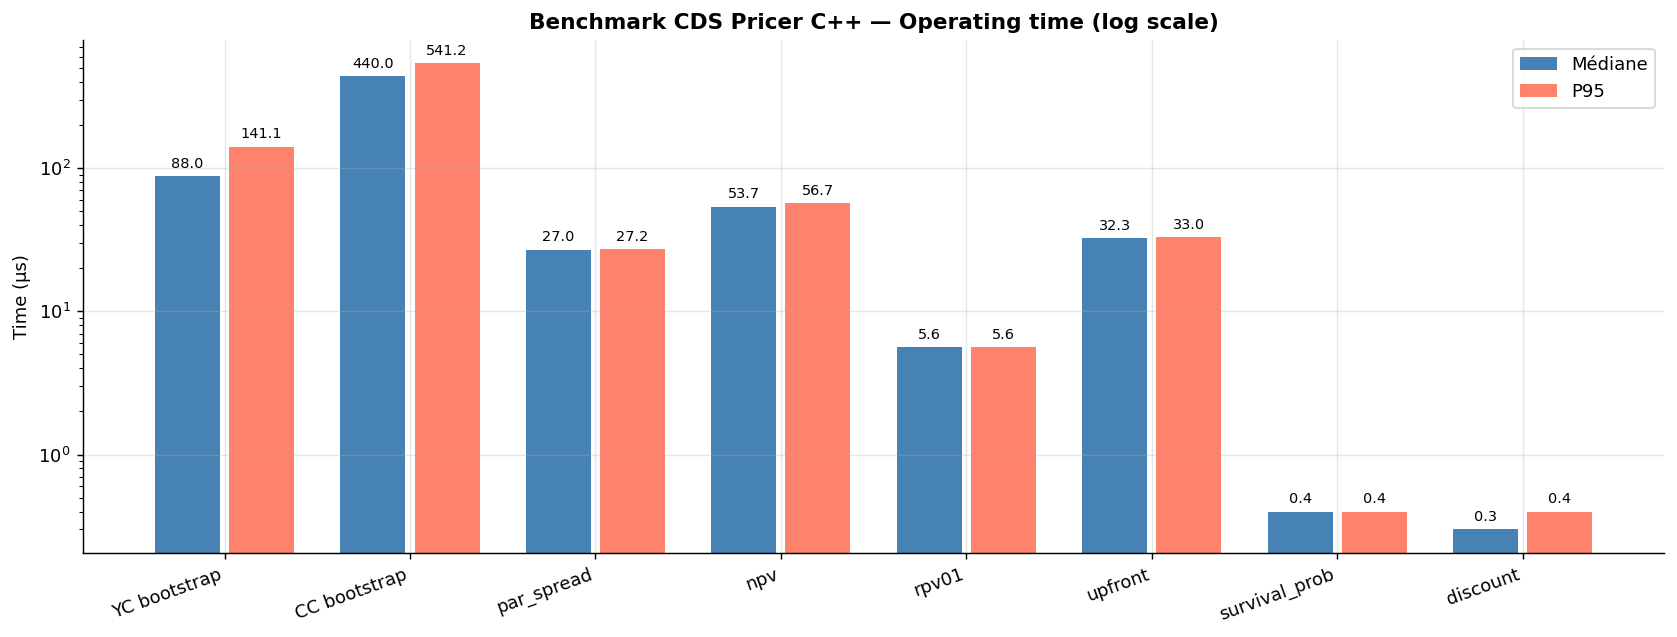

In [12]:
labels  = ['YC bootstrap','CC bootstrap','par_spread','npv','rpv01','upfront','survival_prob','discount']
medians = [statistics.median(t) for t in [t_boot_yc,t_boot_cc,t_par,t_npv,t_rpv01,t_upfront,t_surv,t_disc]]
p95s    = [sorted(t)[int(0.95*N)] for t in [t_boot_yc,t_boot_cc,t_par,t_npv,t_rpv01,t_upfront,t_surv,t_disc]]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(13,5))
bars1 = ax.bar(x-0.2, medians, 0.35, label='Médiane', color='steelblue')
bars2 = ax.bar(x+0.2, p95s,    0.35, label='P95',     color='tomato', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Time (µs)'); ax.set_yscale('log')
ax.set_title('Benchmark CDS Pricer C++ — Operating time (log scale)', fontweight='bold')
ax.legend()
ax.bar_label(bars1, fmt='%.1f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.1f', padding=3, fontsize=8)
plt.tight_layout(); plt.show()

## 3. Yield curve , Discount factors and zero rates

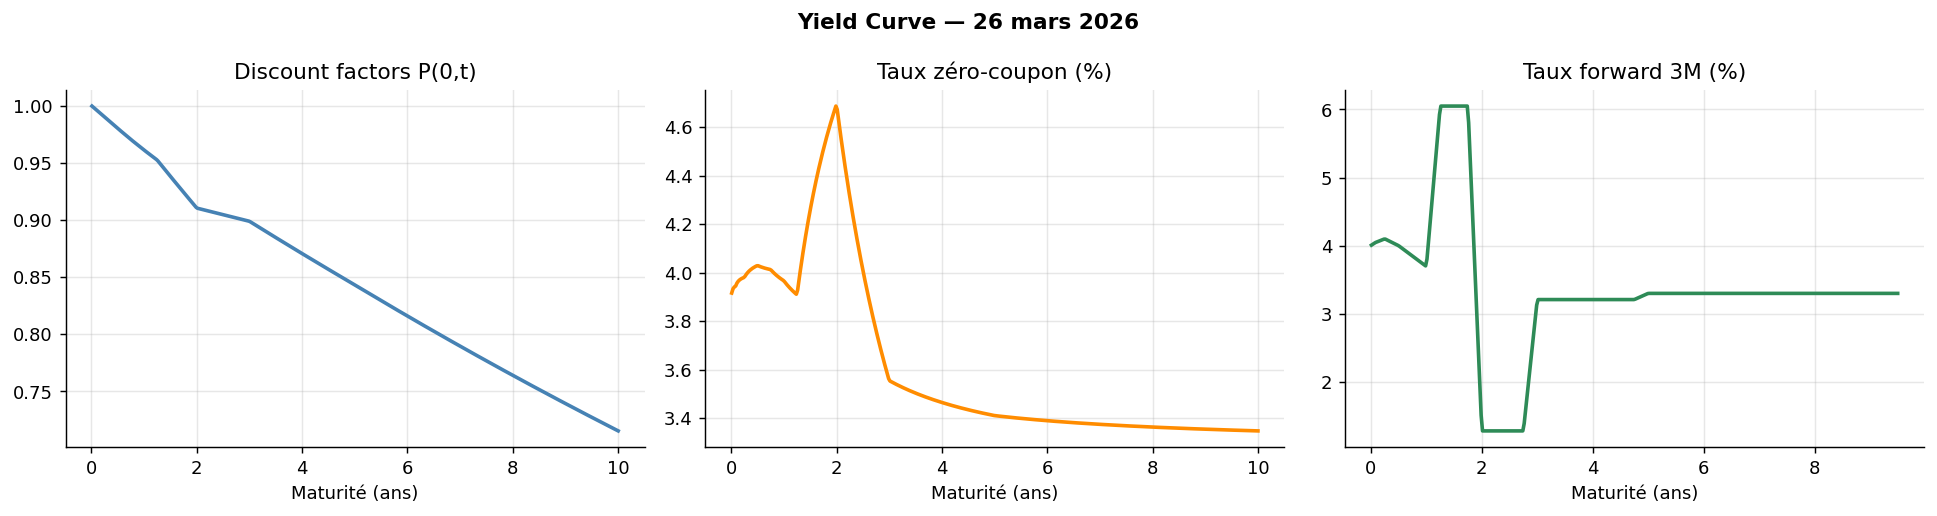

In [13]:
t_grid = np.linspace(0.01, 10, 400)
dfs    = np.array([yc.discount(t) for t in t_grid])
zeros  = -np.log(dfs)/t_grid*100
fwds   = np.array([yc.forward_rate(t, t+0.25)*100 for t in t_grid[:-20]])

fig, axes = plt.subplots(1,3,figsize=(15,4))
axes[0].plot(t_grid, dfs, color='steelblue', lw=2)
axes[0].set_title('Discount factors P(0,t)'); axes[0].set_xlabel('Maturité (ans)')

axes[1].plot(t_grid, zeros, color='darkorange', lw=2)
axes[1].set_title('Taux zéro-coupon (%)'); axes[1].set_xlabel('Maturité (ans)')

axes[2].plot(t_grid[:-20], fwds, color='seagreen', lw=2)
axes[2].set_title('Taux forward 3M (%)'); axes[2].set_xlabel('Maturité (ans)')

fig.suptitle('Yield Curve — 26 mars 2026', fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Credit curve, survival probability, PD & hazard rate

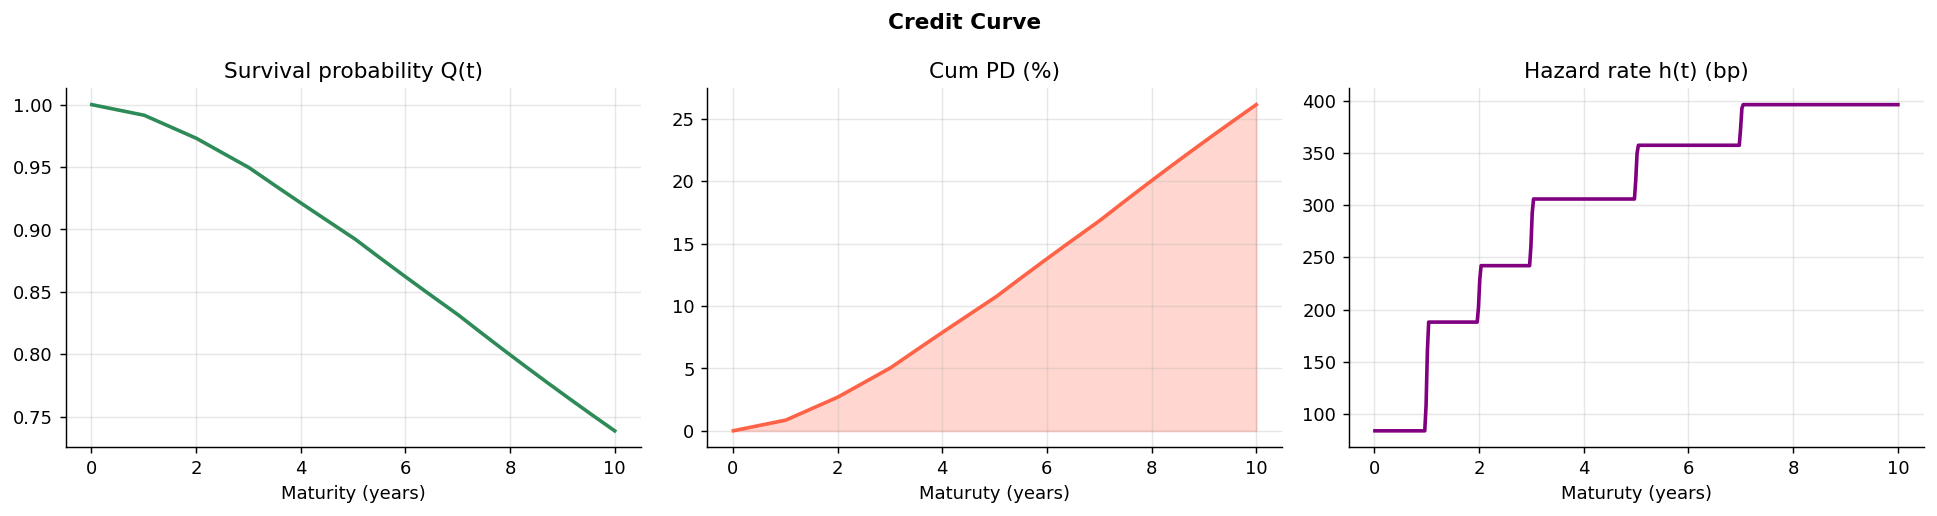

In [14]:
Q      = np.array([cc.survival_probability(t) for t in t_grid])
PD     = (1-Q)*100
hazard = -np.gradient(np.log(Q), t_grid[1]-t_grid[0])*1e4

fig, axes = plt.subplots(1,3,figsize=(15,4))
axes[0].plot(t_grid, Q, color='seagreen', lw=2)
axes[0].set_title('Survival probability Q(t)'); axes[0].set_xlabel('Maturity (years)')

axes[1].fill_between(t_grid, PD, alpha=0.25, color='tomato')
axes[1].plot(t_grid, PD, color='tomato', lw=2)
axes[1].set_title('Cum PD (%)'); axes[1].set_xlabel('Maturuty (years)')

axes[2].plot(t_grid, hazard, color='purple', lw=2)
axes[2].set_title('Hazard rate h(t) (bp)'); axes[2].set_xlabel('Maturuty (years)')

fig.suptitle('Credit Curve ', fontweight='bold')
plt.tight_layout(); plt.show()

## 5. NPV vs Contractual spread

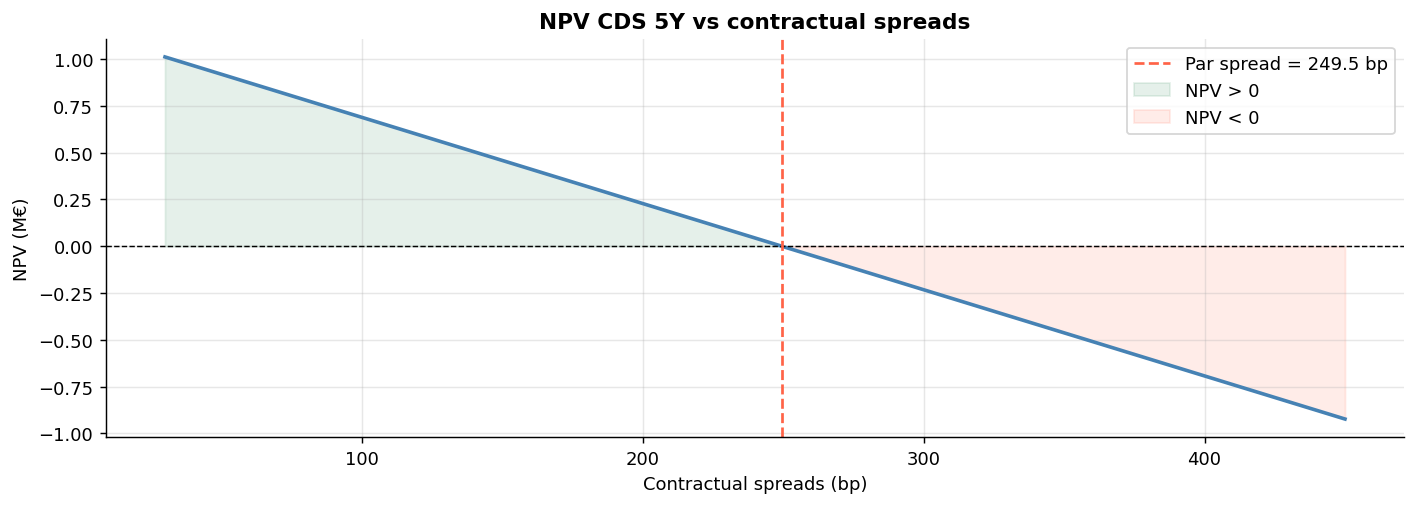

In [15]:
instr5 = make_cds(mat=5.0, spread=0.013)
pricer5 = cds.CDSPricer(instr5, yc, cc)
s_par   = pricer5.par_spread()

spreads_bp = np.linspace(30, 450, 300)
npvs = [pricer5.npv(s/1e4) for s in spreads_bp]

fig, ax = plt.subplots(figsize=(11,4))
ax.plot(spreads_bp, [n/1e6 for n in npvs], color='steelblue', lw=2)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(s_par*1e4, color='tomato', lw=1.5, ls='--', label=f'Par spread = {s_par*1e4:.1f} bp')
ax.fill_between(spreads_bp,[n/1e6 for n in npvs],0,where=[n>0 for n in npvs],alpha=0.12,color='seagreen',label='NPV > 0')
ax.fill_between(spreads_bp,[n/1e6 for n in npvs],0,where=[n<0 for n in npvs],alpha=0.12,color='tomato',label='NPV < 0')
ax.set_title('NPV CDS 5Y vs contractual spreads', fontweight='bold')
ax.set_xlabel('Contractual spreads (bp)'); ax.set_ylabel('NPV (M€)'); ax.legend()
plt.tight_layout(); plt.show()

## 6. Surface NPV, maturity and spread

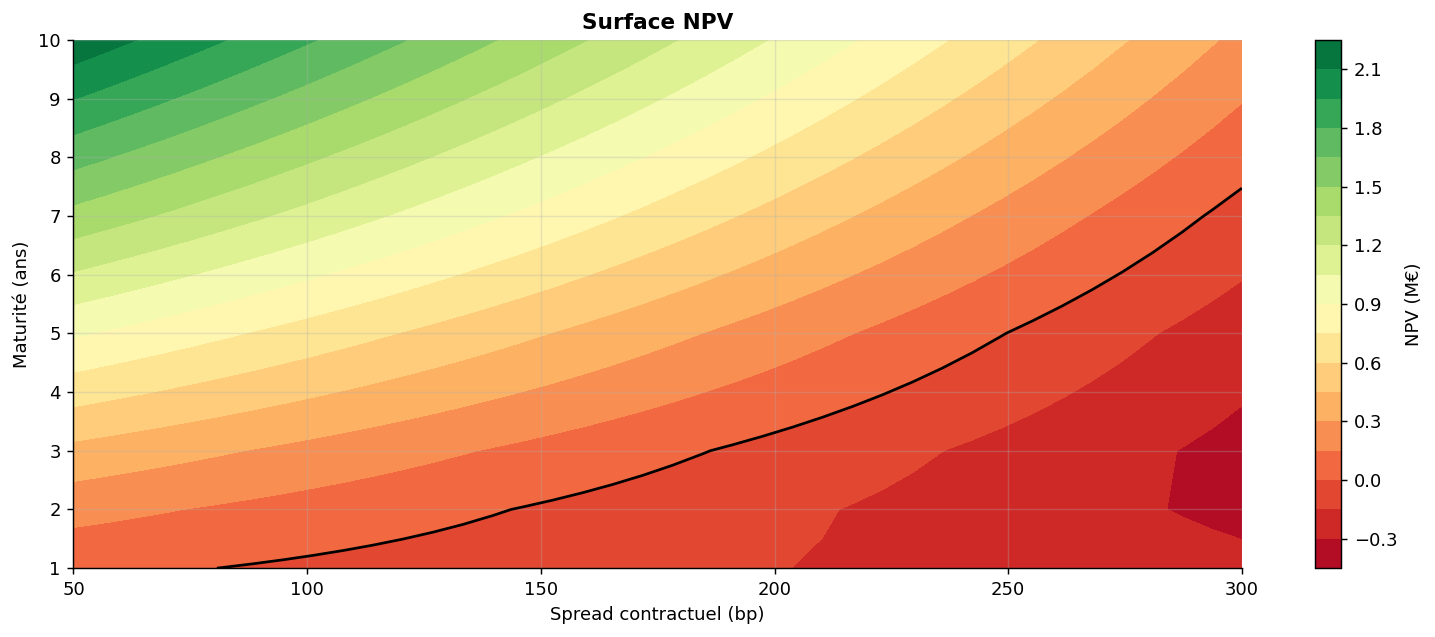

In [16]:
maturities  = np.array([1, 2, 3, 5, 7, 10], dtype=float)
spreads_bp2 = np.linspace(50, 300, 40)
Z = np.zeros((len(maturities), len(spreads_bp2)))

for i, mat in enumerate(maturities):
    instr_m = make_cds(mat=mat, spread=0.013)
    p_m = cds.CDSPricer(instr_m, yc, cc)
    for j, s in enumerate(spreads_bp2):
        Z[i,j] = p_m.npv(s/1e4) / 1e6

fig, ax = plt.subplots(figsize=(12,5))
cs = ax.contourf(spreads_bp2, maturities, Z, levels=20, cmap='RdYlGn')
ax.contour(spreads_bp2, maturities, Z, levels=[0], colors='black', linewidths=1.5)
plt.colorbar(cs, ax=ax, label='NPV (M€)')
ax.set_xlabel('Spread contractuel (bp)'); ax.set_ylabel('Maturité (ans)')
ax.set_title('Surface NPV', fontweight='bold')
plt.tight_layout(); plt.show()